# Chapter 16: Raster-Vector Integration Patterns

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Choose the right substrate for a task, and convert between raster and vector when a workflow needs both
- Compute zonal statistics and class percentages from a real raster onto a real cellular grid
- Build a real distance-to-driver variable and explain when a vector or raster route computes it faster
- Name these patterns the way TerraME's `fill()` names them, and place them against dissmodel's own `fill()` and DisSCube's operator table

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio import features
from rasterstats import zonal_stats
from shapely.geometry import Point

## When to Use Which Substrate

Every chapter since Chapter 6 has picked one substrate — vector or raster — and stayed there for the whole chapter. Real analyses rarely get that luxury: a land-cover study needs a **regular grid** to run a cellular automaton on, but the data describing that grid's cities, rivers, and land cover almost never arrives already gridded. It arrives as a shapefile of municipalities, a raster from a satellite, a table of point locations — three different substrates that a single model still has to reconcile onto one grid.

This chapter works with two real datasets throughout, chosen because a real LUCC model would use exactly this pair: a **30 km regular grid over the state of Amazonas** (the model's cellular substrate) and **LUCCMEBR**, the same Brazil-wide land-cover NetCDF from Chapter 9 (the driver data the grid needs filled in from).

EPSG:5880 (1918, 6)


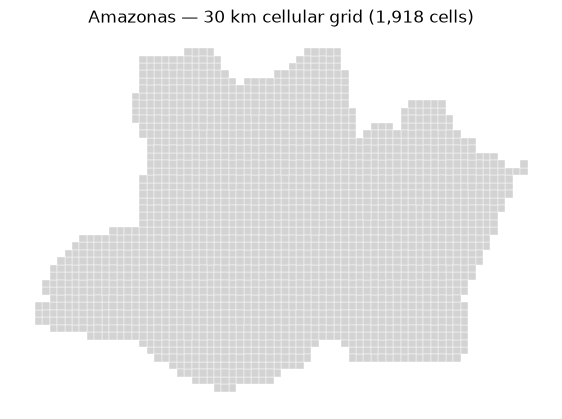

In [2]:
# The cellular substrate: a real 30km grid over Amazonas, 1918 cells
amazonas_grid = gpd.read_file("amazonas_grid_30km.zip")
print(amazonas_grid.crs, amazonas_grid.shape)

fig, ax = plt.subplots(figsize=(7, 7))
amazonas_grid.plot(ax=ax, edgecolor="white", linewidth=0.3, facecolor="lightgray")
ax.set_title("Amazonas — 30 km cellular grid (1,918 cells)")
ax.set_axis_off()

`amazonas_grid` is already a `CellularSpace` in every sense the rest of this book has used the term — 1,918 square polygons, one row each, ready for a `SpatialModel` to run on directly (Chapter 21). What it does *not* have yet is any actual land-cover information. That has to come from somewhere else: LUCCMEBR, a raster.

## Filling Cells: A Pattern With a Name

Getting a value from a raster (or another vector layer) onto every cell of a grid like `amazonas_grid` is common enough, across enough GIS tools, that it has a name: TerraME calls it **filling cells**, and its [`Layer:fill()`](https://github.com/TerraME/terrame/wiki/Fill) function formalizes exactly four operations — `average` (mean of raster pixels per cell), `coverage` (percentage of each category per cell, for categorical rasters), `distance` (distance to the nearest feature of another layer), and `sum` with `area = true` (area-weighted redistribution of a polygon attribute, conserving totals — useful for population).

This chapter builds each of those four operations from lower-level building blocks — `rasterstats`, `rasterio.features`, `shapely` — so that later, when Chapter 30 introduces DisSCube's own named operator table, the connection is between two things you've actually built by hand, not between one you built and one you're told to trust.

## Vector to Raster: rasterio.features.rasterize()

`rasterio.features.rasterize()` burns vector geometries into a raster array — every pixel gets the attribute value of whichever polygon contains it. Here it burns `amazonas_grid`'s own `id` column, at the grid's real 30 km resolution, as a sanity check: the number of distinct nonzero pixels afterward should equal the number of cells.

In [3]:
from affine import Affine

bounds = amazonas_grid.total_bounds
resolution = 30_000  # meters — matches the grid's own cell size
width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)
transform = Affine(resolution, 0, bounds[0], 0, -resolution, bounds[3])

id_raster = features.rasterize(
    [(geom, value) for geom, value in zip(amazonas_grid.geometry, amazonas_grid["id"])],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="int32",
)

print(f"raster shape: {id_raster.shape}  ({height * width} pixels)")
print(f"nonzero pixels: {(id_raster != 0).sum()}  vs. {len(amazonas_grid)} grid cells")

raster shape: (46, 66)  (3036 pixels)
nonzero pixels: 1918  vs. 1918 grid cells


The counts match exactly — every cell claimed exactly one pixel at this resolution, with no gaps and no overlaps, because the raster's resolution was deliberately chosen to equal the grid's own cell size.

## Raster to Vector: rasterio.features.shapes()

`features.shapes()` runs the conversion in reverse: it groups adjacent same-valued pixels into polygons. Applied to `id_raster`, it should recover something close to the original 1,918 grid cells.

In [4]:
shapes_generator = features.shapes(id_raster.astype("int32"), transform=transform)
recovered_ids = [value for geom, value in shapes_generator if value != 0]
print(f"recovered {len(recovered_ids)} non-background polygons from the raster")

recovered 1918 non-background polygons from the raster


Exactly 1,918 recovered polygons — the round trip is lossless here because every original cell was already a raster-aligned square. That won't hold for arbitrary polygon shapes (a coastline rasterized at a coarse resolution loses its curve), but it confirms the mechanics work before layering anything more complex on top.

## Zonal Statistics: Filling by Average

TerraME's `average` operation, done by hand: for every cell in `amazonas_grid`, what fraction of the underlying LUCCMEBR pixels is forest? `rasterstats.zonal_stats()` answers this directly, given a vector layer, a raster array, and that raster's affine transform.

The one real gotcha: LUCCMEBR's `lat` coordinate runs south-to-north (ascending), the opposite of the north-up convention `rasterio`-family tools assume. Flip it first, or every zonal query silently reads from the wrong rows.

In [5]:
luccmebr = xr.open_dataset("LUCCMEBR_land_cover_type_100km2_2000.nc", decode_times=False)

def prep_band(varname):
    """Select one class, drop the singleton time dim, flip to north-up, attach a CRS."""
    band = luccmebr[varname].squeeze("time")
    band = band.reindex(lat=band.lat[::-1])
    return band.rio.write_crs("EPSG:4326")

# LUCCMEBR ships in WGS84 (lat/lon); the grid is in a projected CRS (meters).
# zonal_stats needs both in the same CRS, so reproject the grid, not the raster —
# reprojecting a categorical/fractional raster risks smearing values across a new grid.
amazonas_4326 = amazonas_grid.to_crs("EPSG:4326")

forest = prep_band("veg")  # LUCCMEBR's "veg" = natural forest vegetation
stats = zonal_stats(amazonas_4326, forest.values, affine=forest.rio.transform(), stats="mean", nodata=np.nan)
amazonas_grid["forest_pct"] = [s["mean"] for s in stats]

amazonas_grid["forest_pct"].describe()

count    1918.000000
mean        0.911509
std         0.170756
min         0.000000
25%         0.906698
50%         0.984931
75%         1.000000
max         1.000000
Name: forest_pct, dtype: float64

Amazonas comes back almost entirely forested — a mean forest fraction above 0.9 across the 1,918 cells — which is exactly the kind of sanity check a real LUCC modeler runs before trusting a driver variable: does the aggregated number match what everyone already knows about the region? A wildly different value here would mean a units mismatch or a CRS mistake, not a genuine finding.

One label deserves a flag: LUCCMEBR's own `fores` variable is *not* the forest class — it stands for **forestry** (managed timber plantation), a small, separate category from `veg` (natural forest vegetation). Reading a dataset's actual field documentation before zonal-averaging it is not optional; a plausible-sounding column name is not the same as a verified one.

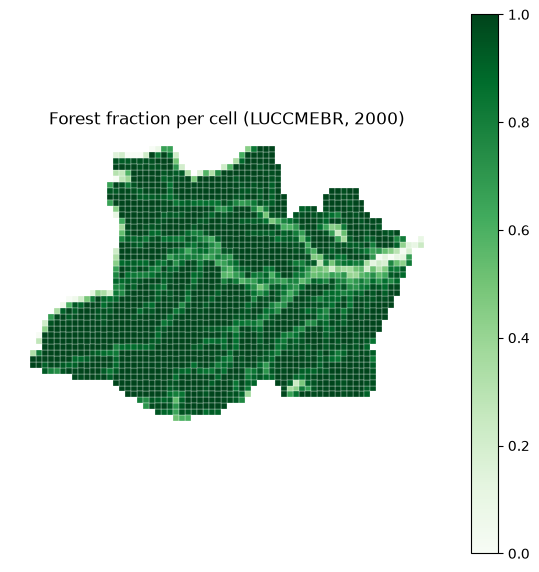

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
amazonas_grid.plot(column="forest_pct", cmap="Greens", legend=True, ax=ax, edgecolor="white", linewidth=0.2)
ax.set_title("Forest fraction per cell (LUCCMEBR, 2000)")
ax.set_axis_off()

## Filling by Coverage: Percentage per Class

TerraME's `coverage` operation is built for *categorical* rasters — one pixel, one class, and the operation counts what share of each cell's pixels falls in each category. LUCCMEBR is subtly different: each of its seven bands is already a **continuous fraction per class**, not a single categorical code per pixel. The honest equivalent here is an `average` fill repeated once per class, then a check that the seven fractions sum close to 1 for every cell — the same guarantee `coverage` gives directly on a categorical raster.

In [7]:
class_vars = {
    "veg": "forest", "gveg": "grassland", "pastp": "pasture",
    "agric": "agriculture", "mosc": "mosaic", "fores": "forestry", "others": "other",
}

for var, label in class_vars.items():
    band = prep_band(var)
    s = zonal_stats(amazonas_4326, band.values, affine=band.rio.transform(), stats="mean", nodata=np.nan)
    amazonas_grid[f"pct_{label}"] = [x["mean"] for x in s]

pct_columns = [f"pct_{label}" for label in class_vars.values()]
row_sums = amazonas_grid[pct_columns].sum(axis=1)
print("class-fraction row sums (should be close to 1.0):")
print(row_sums.describe())

amazonas_grid["dominant_class"] = amazonas_grid[pct_columns].idxmax(axis=1)
amazonas_grid["dominant_class"].value_counts()

class-fraction row sums (should be close to 1.0):
count    1918.000000
mean        0.980870
std         0.111127
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64


dominant_class
pct_forest       1877
pct_other          34
pct_grassland       7
Name: count, dtype: int64

1,877 of the 1,918 cells are forest-dominant; the rest split mostly into `other` (34 cells) and `grassland` (7). That's not evenly scattered noise — it's worth checking whether it lines up with something else the grid already knows.

## Filling by Distance: A Real Driver Variable

TerraME's `distance` operation answers a different question: not "what covers this cell," but "how far is this cell from something else." A LUCC model almost always wants a distance-to-city or distance-to-road driver, because land-cover change concentrates near infrastructure. This section builds distance to Manaus — the real state capital of Amazonas, not a placeholder point — for every cell.

In [8]:
manaus = gpd.GeoDataFrame(
    {"name": ["Manaus"]}, geometry=[Point(-60.0217, -3.1019)], crs="EPSG:4326"
).to_crs(amazonas_grid.crs)

amazonas_grid["dist_manaus_km"] = amazonas_grid.geometry.centroid.distance(manaus.geometry.iloc[0]) / 1000
amazonas_grid["dist_manaus_km"].describe()

count    1918.000000
mean      683.483346
std       352.213838
min        15.082061
25%       385.272720
50%       650.904396
75%       962.789972
max      1582.053376
Name: dist_manaus_km, dtype: float64

In [9]:
other_dominant = amazonas_grid[amazonas_grid["dominant_class"] == "pct_other"]
print(f"'other'-dominant cells: mean distance to Manaus = {other_dominant['dist_manaus_km'].mean():.0f} km")
print(f"all cells:              mean distance to Manaus = {amazonas_grid['dist_manaus_km'].mean():.0f} km")

'other'-dominant cells: mean distance to Manaus = 429 km
all cells:              mean distance to Manaus = 683 km


The non-forest cells sit noticeably closer to Manaus on average (roughly 430 km versus 683 km for the grid as a whole) — exactly the pattern that justifies putting `dist_manaus_km` into a LUCC model's driver set in the first place (Chapter 26 does precisely this, with roads in place of a single city). One real point and one `.distance()` call recovered a relationship a modeler would otherwise have to take on faith.

## Performance Patterns for Integration

Every driver above was one vectorized `zonal_stats` or `.distance()` call across all 1,918 cells at once. The naive alternative — loop over cells, and for each one loop over some reference set of points computing distance by hand — is the same O(cells × references) trap Chapter 20 diagnosed for a hand-rolled cellular automaton. At 1,918 cells against a single point the naive version is still instant; the scaling argument is the real lesson, not the stopwatch. Add a real road network with thousands of segments as the reference layer instead of one point, and the gap between a vectorized `distance_transform_edt` (Chapter 8) and a nested Python loop stops being academic.

## A Bridge Ahead: Naming These Patterns in DisSModel

Everything above was built from general-purpose tools — `rasterstats`, `shapely`, `.distance()` — deliberately, because Part II's whole pitch is a geographic-data-science toolkit that needs no simulation framework at all. Volume II picks the same four ideas back up and gives them names inside `dissmodel` itself: [`dissmodel.geo.vector.fill()`](https://dissmodel.github.io/dissmodel/api/geo/vector/#dissmodel.geo.vector.fill) dispatches on a `FillStrategy` enum — `ZONAL_STATS` for the *average* pattern, `MIN_DISTANCE` for the *distance* pattern this chapter just built by hand, plus `RANDOM_SAMPLE` and `PATTERN` for seeding a model's initial state, which have no equivalent in this chapter at all.

A separate, higher-level package, [DisSCube](https://github.com/DisSModel/disscube), goes further still — cataloged, cached derivations instead of one-off fills — with its own operator table (`mean`, `percentage`, `sum`, `min_distance`...) for exactly the *coverage* and area-weighted *sum* patterns `dissmodel.geo.vector.fill()` doesn't cover. Both are worth knowing exist; neither is needed to finish Part II.

## Exercises

1. **A different class.** Repeat the *Filling by Average* section using `pastp` (planted pasture) instead of `veg`. Does its spatial pattern relative to distance from Manaus look similar to, or different from, the `other`-dominant pattern found above?
2. **Verify the flip.** Comment out the `band.reindex(lat=band.lat[::-1])` line in `prep_band()` and rerun the zonal stats for `veg`. How badly do the results break, and does anything about the output make the mistake obvious without comparing to the correct version?
3. **A second driver.** Amazonas' other major city is Manacapuru. Look up its coordinates and add a second `dist_manacapuru_km` column the same way `dist_manaus_km` was built. Do the two distance columns correlate strongly, or do they carry meaningfully different information?
4. **Coverage sums below 1.** A few cells' `row_sums` came in visibly below 1.0. Map `row_sums` directly (`amazonas_grid.plot(column=...)`) — do the low-sum cells cluster at the edge of the grid, matching a boundary/nodata effect, or somewhere else entirely?

## Summary

### Key concepts introduced

- A rule of thumb for substrate choice: vector for exact, discrete boundaries; raster for continuous fields sampled on a regular grid
- `rasterio.features.rasterize()` and `features.shapes()` as the vector↔raster round trip, verified lossless on a raster-aligned grid
- Zonal statistics (`rasterstats.zonal_stats`) as TerraME's `average` operation, computed on a real LUCCMEBR class over a real 1,918-cell Amazonas grid
- Repeated zonal averaging across all seven LUCCMEBR classes as the fractional-raster equivalent of TerraME's `coverage` operation, checked by summing to ~1.0
- A real distance-to-city driver variable (`dist_manaus_km`), and the empirical pattern it revealed in non-forest cells
- DisSCube's operator table (Chapter 30) as the same four TerraME `fill()` patterns turned into named, cached, reproducible operations — with one documented gap: vector-source aggregation there is pixel-counted, not area-weighted

Chapter 17 leaves Part II's data-science toolkit behind and turns to the paradigms — cellular automata, system dynamics, agent-based models — that Part III builds directly on top of everything gathered so far.

## Further Reading

- Andrade, P. R., & Avancini, R., *Creating and Filling Cellular Spaces in TerraME*: <https://github.com/TerraME/terrame/wiki/Fill> — the original `fill()` vocabulary this chapter builds from lower-level tools
- DisSModel API reference, *Geo — Vector*, `dissmodel.geo.vector.fill`: <https://dissmodel.github.io/dissmodel/api/geo/vector/#dissmodel.geo.vector.fill> — the framework's own direct counterpart to TerraME's `fill()`
- DisSCube documentation, *Operadores disponíveis*: <https://github.com/DisSModel/disscube> — the DisSModel ecosystem's higher-level, cataloged operator table and its documented limitations
- rasterstats documentation, *Zonal Statistics*: <https://pythonhosted.org/rasterstats/manual.html#zonal-statistics>
- rasterio documentation, *Feature extraction*: <https://rasterio.readthedocs.io/en/stable/topics/features.html>